In [1]:
from time import perf_counter

import jax
import jax.numpy as jnp
import optax
import jax.tree_util as jtu
from furax._base.dense import DenseBlockDiagonalOperator
from furax.components import (
    CMB,
    CMBParam,
    Dust,
    DustParam,
    SpectralParameters,
    MixingMatrixOperator,
    SynchParams,
    Synchrotron,
)
from furax.instruments.sky import FGBusterInstrumentPytree, get_observation
from furax.landscapes import StokesIQUPyTree
from furax.operators import HomothetyOperator

In [2]:
nside = 4
npix = 12 * nside**2
stokes = 'IQU'
instrument = FGBusterInstrumentPytree.default_instrument()
d = get_observation(
    instrument,
    nside,
    tag='c1d0s0',
    stokes_type=stokes,
    add_noise=False,
    unit='uK_CMB',
    dtype=jnp.float64,
)
nu = instrument.frequency

In [3]:
DUST_LOWER_BOUND = 0.5
DUST_UPPER_BOUND = 3.0
TEMP_LOWER_BOUND = 1.0
TEMP_UPPER_BOUND = 50.0
BETA_PL_LOWER_BOUND = -6.0
BETA_PL_UPPER_BOUND = -1.0

In [4]:
beta_dust = jax.random.uniform(
    jax.random.PRNGKey(0), shape=(1,), dtype=jnp.float64, minval=0.5, maxval=3.0
)
temp_dust = jax.random.uniform(
    jax.random.PRNGKey(1), shape=(1,), dtype=jnp.float64, minval=1.0, maxval=50.0
)
beta_pl = jax.random.uniform(
    jax.random.PRNGKey(2), shape=(1,), dtype=jnp.float64, minval=-6.0, maxval=-1.0
)

dust_param = DustParam(beta_d=beta_dust, temp_d=temp_dust)
synch_param = SynchParams(beta_pl=beta_pl)
cmb_param = CMBParam.zeros(size=npix, dtype=jnp.float64)
mixing_matrix = SpectralParameters(cmb_param, dust_param, synch_param)

In [5]:
nu0 = 30.0
cmb = CMB(units='K_CMB')
dust = Dust(nu0=nu0, units='K_CMB')
synch = Synchrotron(nu0=nu0, units='K_CMB')
mixing_matrix_op = MixingMatrixOperator(cmb, dust, synch)

In [7]:
invN = HomothetyOperator(jnp.ones(1), _in_structure=d.structure)
DND = invN(d) @ d
DND

Array(3.18761012e+09, dtype=float64)

In [9]:
@jax.jit
def likelihood(mixing_matrix, nu, d):
    A_blocks = mixing_matrix_op(nu, mixing_matrix)
    in_stucture = StokesIQUPyTree.structure_for((len(mixing_matrix), npix), jnp.float64)
    A = DenseBlockDiagonalOperator(
        A_blocks,
        in_stucture,
        'fc,cp->fp',
    )

    AND = (A.T @ invN)(d)
    ANA = (A.T @ invN @ A).I(AND)

    spectral_likehood = jax.tree.map(lambda x, y: x * y, AND, ANA)  
    spectral_likehood_IQU = sum(jax.tree.leaves(spectral_likehood)) 
    spectral_likehood_summed = jnp.mean(spectral_likehood_IQU) 
    return -spectral_likehood_summed  + DND

In [10]:
likelihood(mixing_matrix, nu, d).block_until_ready()
%timeit likelihood(mixing_matrix, nu, d).block_until_ready()

Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in

In [11]:
jax.grad(spectral_likehood_obj)(mixing_matrix, nu, d).Dust.temp_d.block_until_ready()
%timeit jax.grad(spectral_likehood_obj)(mixing_matrix, nu, d).Dust.temp_d.block_until_ready()

Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in 4 iterations
Converged in

In [19]:
%timeit spectral_likehood_obj(mixing_matrix, nu, d).block_until_ready()

825 μs ± 75.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [20]:
%%timeit
grads = jax.grad(spectral_likehood_obj)(mixing_matrix, nu, d)
grads.Dust.temp_d.block_until_ready()

11.4 ms ± 516 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [34]:
PROJECT_PARAMS = False
scheduler = optax.cosine_decay_schedule(2.0, 200, alpha=0.01)
solver = optax.adam(learning_rate=0.1)
opt_state = solver.init(mixing_matrix)
spectral_likehoods = []
beta_dusts = []
temp_dusts = []
beta_pls = []

gradient_to_likelyhood_ratio_beta_dusts = []
gradient_to_likelyhood_ratio_temp_dusts = []
gradient_to_likelyhood_ratio_beta_pls = []

In [36]:
start = perf_counter()
for epoch in range(2000):
    spectral_likehood, grad = jax.value_and_grad(spectral_likehood_obj)(mixing_matrix, nu, d)
    updates, opt_state = solver.update(grad, opt_state, mixing_matrix)
    mixing_matrix = optax.apply_updates(mixing_matrix, updates)
    value_flat, value_tree = jtu.tree_flatten(mixing_matrix)
    if PROJECT_PARAMS:
        beta_d = optax.projections.projection_box(value_flat[0], DUST_LOWER_BOUND, DUST_UPPER_BOUND)
        temp_d = optax.projections.projection_box(value_flat[1], TEMP_LOWER_BOUND, TEMP_UPPER_BOUND)
        beta_pl = optax.projections.projection_box(
            value_flat[2], BETA_PL_LOWER_BOUND, BETA_PL_UPPER_BOUND
        )
        mixing_matrix = jtu.tree_unflatten(value_tree, (beta_d, temp_d, beta_pl))

    gradient_to_likelyhood_ratio_beta_dust = (grad.Dust.beta_d)[0]
    gradient_to_likelyhood_ratio_temp_dust = (grad.Dust.temp_d)[0]
    gradient_to_likelyhood_ratio_beta_pl = (grad.Synchrotron.beta_pl)[0]

    spectral_likehoods.append(spectral_likehood)
    beta_dusts.append(mixing_matrix.Dust.beta_d[0])
    temp_dusts.append(mixing_matrix.Dust.temp_d[0])
    beta_pls.append(mixing_matrix.Synchrotron.beta_pl[0])

    gradient_to_likelyhood_ratio_beta_dusts.append(gradient_to_likelyhood_ratio_beta_dust)
    gradient_to_likelyhood_ratio_temp_dusts.append(gradient_to_likelyhood_ratio_temp_dust)
    gradient_to_likelyhood_ratio_beta_pls.append(gradient_to_likelyhood_ratio_beta_pl)

    # if jax.tree.all(jax.tree.map(lambda x: jnp.abs(x).max() < 1e-3, grad)):
    #    break
    print(
        f'Iteration {epoch} - Spectral likelihood: {spectral_likehood} params: {mixing_matrix.Dust}, {mixing_matrix.Synchrotron}'
    )
    print(f'Grads {grad.Dust}, {grad.Synchrotron}')

end = perf_counter()
print(
    f'Converged in {epoch} epochs with parameters: {mixing_matrix.Dust}, {mixing_matrix.Synchrotron} in {(end - start)*1000} ms'
)

Iteration 0 - Spectral likelihood: -0.005787036912857998 params: DustParam(beta_d=Array([1.50101924], dtype=float64), temp_d=Array([22.21459128], dtype=float64)), SynchParams(beta_pl=Array([-2.99633454], dtype=float64))
Grads DustParam(beta_d=Array([-2.34800879e-11], dtype=float64), temp_d=Array([9.87314247e-11], dtype=float64)), SynchParams(beta_pl=Array([3.66353576e-13], dtype=float64))
Iteration 1 - Spectral likelihood: -0.005787036912936088 params: DustParam(beta_d=Array([1.50103163], dtype=float64), temp_d=Array([22.21380496], dtype=float64)), SynchParams(beta_pl=Array([-2.99633568], dtype=float64))
Grads DustParam(beta_d=Array([-2.34837403e-11], dtype=float64), temp_d=Array([9.87090456e-11], dtype=float64)), SynchParams(beta_pl=Array([4.83123844e-13], dtype=float64))
Iteration 2 - Spectral likelihood: -0.005787036913014109 params: DustParam(beta_d=Array([1.50104402], dtype=float64), temp_d=Array([22.21301872], dtype=float64)), SynchParams(beta_pl=Array([-2.99633684], dtype=float6

In [110]:
mixing_matrix

MixingMatrix(CMB=CMBParam(), Dust=DustParam(beta_d=Array([1.53849668], dtype=float64), temp_d=Array([20.07673558], dtype=float64)), Synchrotron=SynchParams(beta_pl=Array([-2.99985672], dtype=float64)))

In [111]:
import matplotlib.pyplot as plt


def plot(data_dict, filename=None):
    """
    Function to visualize multiple lists over epochs.

    Parameters:
    - data_dict: Dictionary where keys are plot labels and values are lists to plot.
    - epochs: List or array of epochs (x-axis).
    - filename: Optional. If provided, the plot will be saved as this filename.
    """
    n = len(data_dict)

    assert len({len(v) for v in data_dict.values()}) == 1, 'All lists must have the same length'
    epochs = range(len(next(iter(data_dict.values()))))

    # Determine the number of rows and columns
    if n == 1:
        rows, cols = 1, 1
    else:
        rows = (n // 3) + (1 if n % 3 != 0 else 0)
        cols = 3 if n > 1 else 1

    fig, axs = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axs = axs.ravel() if n > 1 else [axs]

    for i, (key, values) in enumerate(data_dict.items()):
        axs[i].plot(epochs, values, label=key)
        axs[i].set_title(f'{key} Over Epochs')
        axs[i].set_xlabel('Epochs')
        axs[i].set_ylabel('Value')
        axs[i].grid(True)

        # Annotate the final value
        last_value = values[-1]
        axs[i].text(
            len(epochs),
            last_value,
            f'{last_value:.2f}',
            ha='left',
            va='center',
            fontsize=10,
            color='b',
        )

    plt.tight_layout()
    plt.show()

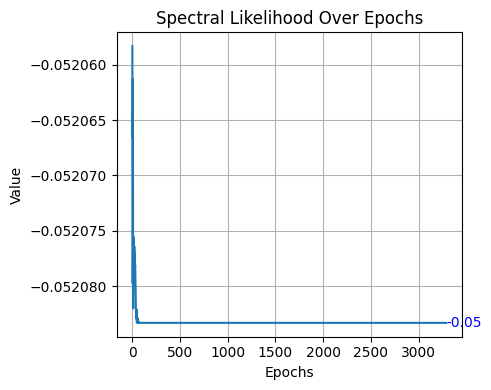

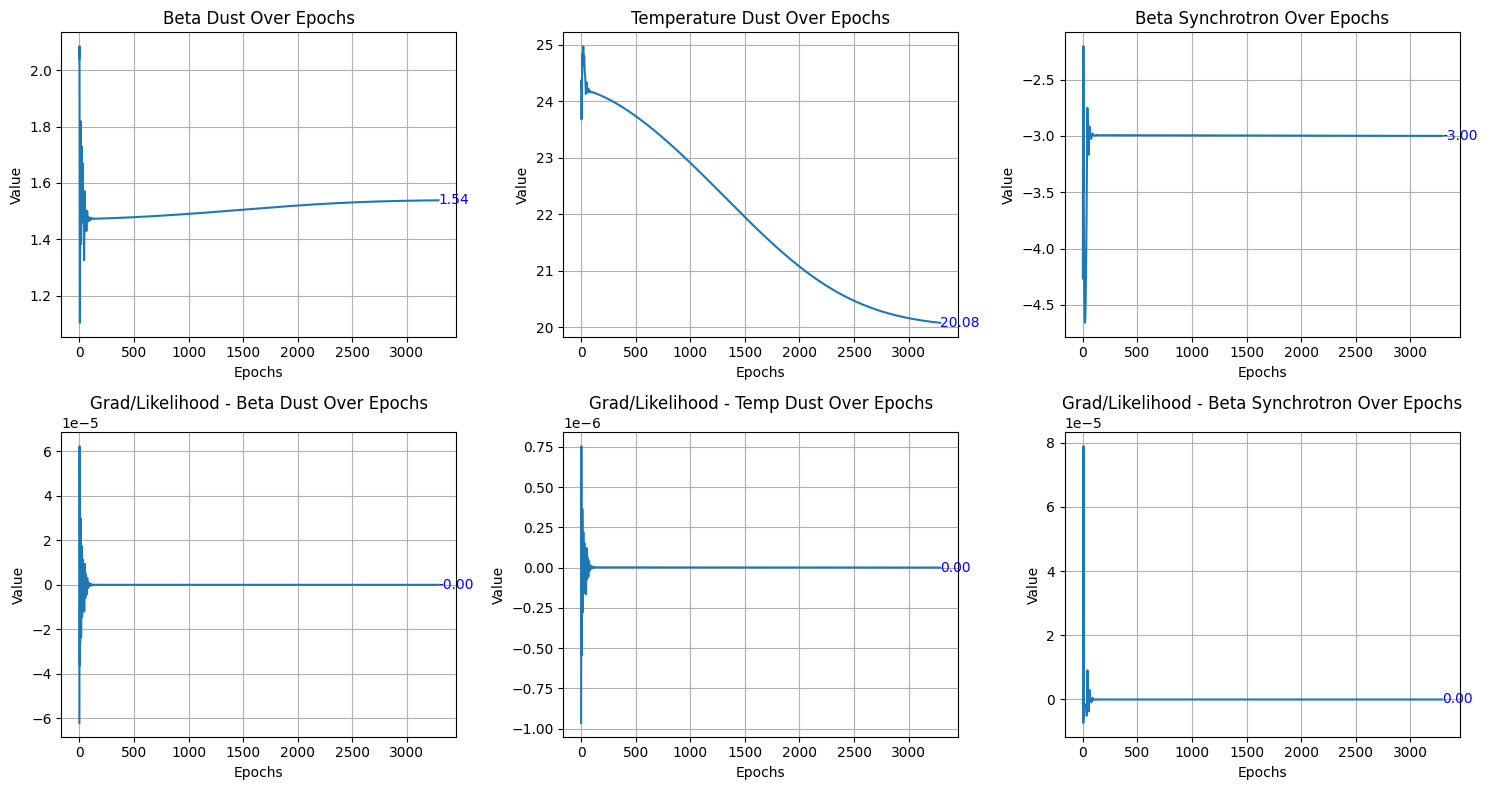

In [112]:
spectral_likehoods_dict = {'Spectral Likelihood': spectral_likehoods}
params_dict = {
    'Beta Dust': beta_dusts,
    'Temperature Dust': temp_dusts,
    'Beta Synchrotron': beta_pls,
    'Grad/Likelihood - Beta Dust': gradient_to_likelyhood_ratio_beta_dusts,
    'Grad/Likelihood - Temp Dust': gradient_to_likelyhood_ratio_temp_dusts,
    'Grad/Likelihood - Beta Synchrotron': gradient_to_likelyhood_ratio_beta_pls,
}

plot(spectral_likehoods_dict, 'spectral_likelihood_over_epochs.png')
plot(params_dict, 'params_and_grad_likelihood_ratios.png')